#📝 Instrucciones
Prediciendo la diabetes
En el proyecto anterior vimos cómo podíamos utilizar un árbol de decisión para predecir conjuntos de datos relacionados con la clasificación y la regresión. Sin embargo, ¿sabías que podemos mejorar la predicción de un árbol utilizando un random forest?

Como hemos estudiado, un random forest es una agrupación de árboles generados con porciones aleatorias de los datos y con criterios también aleatorios. Esta visión nos permitiría mejorar la efectividad del modelo cuando un árbol individual no es suficiente.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el
accuracy
.

Recuerda que el proyecto anterior puedes encontrarlo aquí.

# Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).

# Paso 2: Construye un random forest
Una forma de optimizar y mejorar los resultados cuando usamos árboles de decisión es generar un random forest con árboles suficientes de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los dos hiperparámetros que definen al árbol con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

# Paso 3: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [68]:
#importamos librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

In [69]:
# Cargamos los cuatro archivos que vienen del proyecto anterior
X_train = pd.read_csv('../data/processed/X_train_diabetes.csv')   
X_test  = pd.read_csv('../data/processed/X_test_diabetes.csv')    
y_train = pd.read_csv('../data/processed/y_train_diabetes.csv')  
y_test  = pd.read_csv('../data/processed/y_test_diabetes.csv')   

In [70]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,90.0,62.0,12.0,43.0,27.2,0.580,24
1,5,126.0,78.0,27.0,22.0,29.6,0.439,40
2,2,105.0,58.0,40.0,94.0,34.9,0.225,25
3,1,146.0,56.0,29.0,125.0,29.7,0.564,29
4,0,95.0,64.0,39.0,105.0,44.6,0.366,22


## Entrenamos el modelo random forest 

In [71]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [72]:
# El modelo hace sus predicciones sobre los datos de prueba
y_pred_train = modelo_rf.predict(X_train)   
y_pred_test  = modelo_rf.predict(X_test)    

# Calculamos la accuracy (porcentaje de aciertos)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print('RESULTADOS DEL RANDOM FOREST')
print('─' * 45)
print(f'  Accuracy en entrenamiento : {acc_train:.2%}')
print(f'  Accuracy en prueba        : {acc_test:.2%}')


RESULTADOS DEL RANDOM FOREST
─────────────────────────────────────────────
  Accuracy en entrenamiento : 100.00%
  Accuracy en prueba        : 77.92%


Nota: si el accuracy de entrenamiento es mucho mayor que el de prueba puede existir overfitting.

In [73]:
print('REPORTE COMPLETO DE MÉTRICAS (datos de prueba):')
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(
    y_test, y_pred_test,
    target_names=['No Diabético (0)', 'Diabético (1)']
))

REPORTE COMPLETO DE MÉTRICAS (datos de prueba):
[[88 12]
 [22 32]]
                  precision    recall  f1-score   support

No Diabético (0)       0.80      0.88      0.84       100
   Diabético (1)       0.73      0.59      0.65        54

        accuracy                           0.78       154
       macro avg       0.76      0.74      0.75       154
    weighted avg       0.77      0.78      0.77       154



- la Precision  = de los que predije como diabéticos, ¿cuántos realmente lo eran? pues el 80% 
- el Recall     = de todos los diabéticos reales, ¿cuántos detecté? detecte el 88% 
- el F1-Score   = promedio entre precision y recall

Podemos observar con una matriz de confusion los resultados 

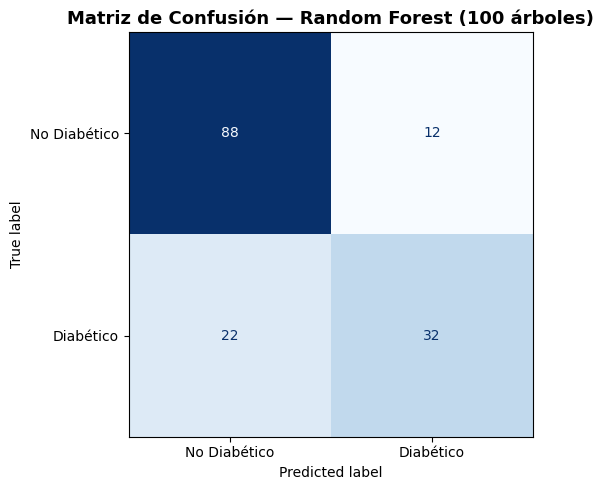


¿Qué significa cada cuadro?
  ✅ Verdadero Negativo  (esquina sup. izq.):  88  → Sanos predichos como sanos
  ❌ Falso Positivo      (esquina sup. der.):  12  → Sanos predichos como diabéticos
  ⚠️  Falso Negativo      (esquina inf. izq.):  22  → Diabéticos predichos como sanos (peor error)
  ✅ Verdadero Positivo  (esquina inf. der.):  32  → Diabéticos predichos como diabéticos


In [74]:
# Matriz de confusión: muestra visualmente los aciertos y errores del modelo
fig, ax = plt.subplots(figsize=(7, 5))

cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabético', 'Diabético'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matriz de Confusión — Random Forest (100 árboles)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Explicación sencilla de la matriz
tn, fp, fn, tp = cm.ravel()
print(f'\n¿Qué significa cada cuadro?')
print(f'  ✅ Verdadero Negativo  (esquina sup. izq.): {tn:3d}  → Sanos predichos como sanos')
print(f'  ❌ Falso Positivo      (esquina sup. der.): {fp:3d}  → Sanos predichos como diabéticos')
print(f'  ⚠️  Falso Negativo      (esquina inf. izq.): {fn:3d}  → Diabéticos predichos como sanos (peor error)')
print(f'  ✅ Verdadero Positivo  (esquina inf. der.): {tp:3d}  → Diabéticos predichos como diabéticos')

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape o

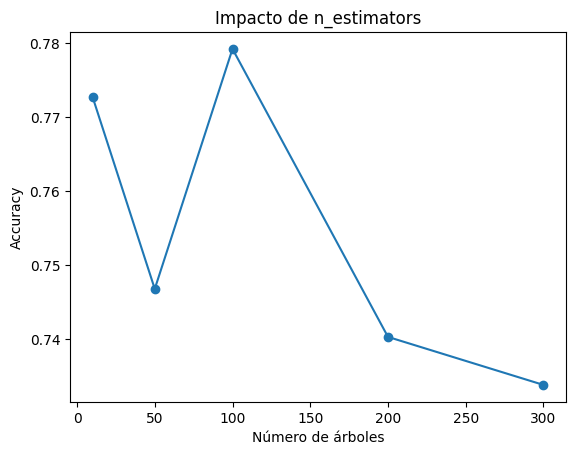

In [75]:
n_trees = [10, 50, 100, 200, 300]
scores = []

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    scores.append(accuracy_score(y_test, pred))

plt.plot(n_trees, scores, marker='o')
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators")
plt.show()

El mejor número de árboles es 100 con una accuracy de 77% en prueba

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape o

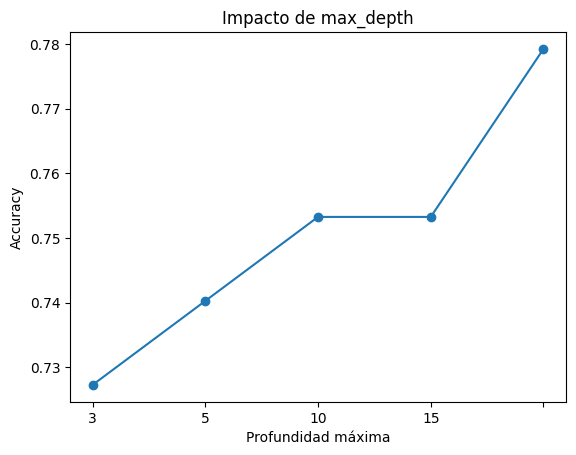

In [76]:
depths = [3, 5, 10, 15, None]
scores_depth = []

for d in depths:
    model = RandomForestClassifier(
        max_depth=d,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    scores_depth.append(accuracy_score(y_test, pred))
plt.plot(range(len(depths)), scores_depth, marker='o')
plt.xticks(range(len(depths)), depths)
plt.xlabel("Profundidad máxima")
plt.ylabel("Accuracy")
plt.title("Impacto de max_depth")
plt.show()

La mejor profundidad es cerca de los 20  con accuracy del  77% en prueba

Conclusiones: tenemos que el modelo es mejor si tiene una profundida cerca a los 20 y un numero de arboles de 100 

/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


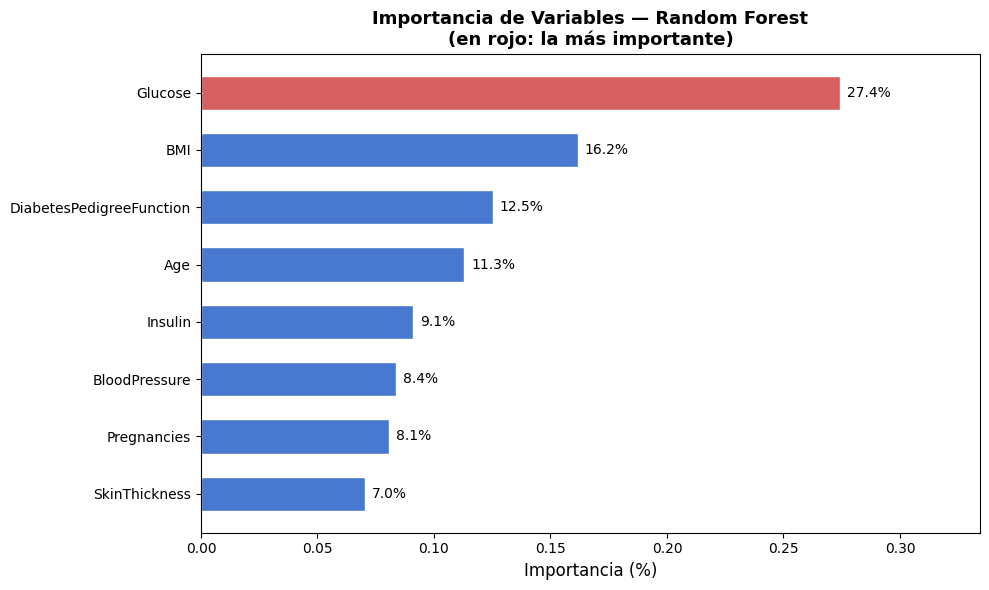

In [77]:
# Entrenamos el modelo final con la mejor configuración que encontramos
modelo_final = RandomForestClassifier(
n_estimators=100, 
max_depth=20,
random_state=42)
modelo_final.fit(X_train, y_train)

# Extraemos la importancia de cada variable
importancias = pd.Series(
    modelo_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)   

# ── Gráfico de barras horizontales ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(importancias.index, importancias.values, color=colores,
                 edgecolor='white', height=0.6)

# Añadimos el porcentaje al final de cada barra
for barra, valor in zip(barras, importancias.values):
    ax.text(valor + 0.003, barra.get_y() + barra.get_height() / 2,
            f'{valor:.1%}', va='center', fontsize=10)

ax.set_xlabel('Importancia (%)', fontsize=12)
ax.set_title('Importancia de Variables — Random Forest\n(en rojo: la más importante)',
             fontweight='bold', fontsize=13)
ax.set_xlim(0, importancias.max() + 0.06)
plt.tight_layout()
plt.show()


¿Qué significa esto? La variable más importante es: GLUCOSE Eso quiere decir que el modelo se basa principalmente en esa variable para decidir si un paciente tiene diabetes o no. Esto coincide con lo que la medicina ya sabe: el nivel de glucosa es el indicador más fiable de diabetes.

In [78]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print('=' * 55)
print('RESUMEN FINAL')
print('=' * 55)
print(f'  Modelo         : Random Forest')
print(f'  Árboles        : 100')
print(f'  Profundidad    : 20 o Sin límite')
print()
print(f'  Accuracy train : {accuracy_score(y_train, modelo_final.predict(X_train)):.2%}')
print(f'  Accuracy test  : {accuracy_score(y_test,  modelo_final.predict(X_test)):.2%}')
print(f'  F1-Score test  : {f1_score(y_test, modelo_final.predict(X_test)):.2%}')
print()
print(f'  Variable más importante: {importancias.idxmax()}')


RESUMEN FINAL
  Modelo         : Random Forest
  Árboles        : 100
  Profundidad    : 20 o Sin límite

  Accuracy train : 100.00%
  Accuracy test  : 77.92%
  F1-Score test  : 65.31%

  Variable más importante: Glucose


Sobre el Random Forest:

- El Random Forest mejora al árbol de decisión simple porque usa la "sabiduría colectiva" de muchos árboles.
- No hay una cantidad perfecta de árboles para siempre, pero a partir de ~100 los resultados se estabilizan.
- Una profundidad muy pequeña (1-2) hace que el modelo sea demasiado simple. Sin límite de profundidad puede causar sobreajuste.

Sobre las variables:

- Glucose sigue siendo la variable más importante para predecir diabetes, tanto en el árbol como en el Random Forest.
- BMI y Age también son factores relevantes.

Cargamos el modelo:

In [80]:
random_forest = joblib.dump(modelo_final, "../models/random_forest_model.pkl")